In [38]:
import mdtraj
import jax.numpy as jnp
import equinox as eqx
import jax
import numpy as np

import cryojax.simulator as cxs
from cryojax.io import read_atoms_from_pdb, read_array_from_mrc
from cryojax.constants import (
    PengScatteringFactorParameters,
    b_factor_to_variance,
)

import mrcfile
from cryojax.ndimage import fourier_crop_to_shape
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
import scipy.spatial.distance
import scipy.ndimage.filters
import copy
from matplotlib import animation
%matplotlib inline
import matplotlib as mpl
from pylab import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [65]:
pdb_file_PE = "../CH1_pointed/starting_structures/CH1_pointed_refstruct_corraligned.pdb"
pdb_file_RF = "../CH1_reverseface/starting_structures/CH1_pointed_reverseface_refstruct_corraligned.pdb"
mrc_density_file = "wtactn4_segmented_weakABD_resampled.mrc"
xtc_files = [
"/scratch/fm1484/fm1484/alpha-actinin/MAPS/extend_NPT/CH1_pointed/extended_frame150/actn4_CH1_pointedend_threeactin_ADP_gromacs_200nsReplica_startframe150_1microsecfull.cat.xtc",
"/scratch/fm1484/fm1484/alpha-actinin/MAPS/extend_NPT/CH1_reverseface/actn4_CH1_reverseface_threeactin_ADP_gromacs_ionC50_NPT_extend_full1microsec.cat.xtc",
]

labels = [
    "CH1 pointed end",
    "CH1 pointed end (reverse face)",
]
selection_string = "chainid 9 and not element H" #mdtraj selection language
pdb_path=[pdb_file_PE, pdb_file_RF]

In [57]:
traj = mdtraj.load(pdb_file_RF)
topology = traj.topology

for chain in topology.chains:
    atoms = list(chain.atoms)
    print(f"Chain {chain.index}: {len(atoms)} atoms, first atom: {atoms[0]}, last atom: {atoms[-1]}")

indices = topology.select("chainid 9 and not element H") # check selection string and adjust accordingly
print(f"Selection matches {len(indices)} atoms")

Chain 0: 5830 atoms, first atom: ASP1-N, last atom: PHE375-OXT
Chain 1: 39 atoms, first atom: ADP376-C4', last atom: ADP376-O3B
Chain 2: 1 atoms, first atom: MG377-MG, last atom: MG377-MG
Chain 3: 5830 atoms, first atom: ASP1-N, last atom: PHE375-OXT
Chain 4: 39 atoms, first atom: ADP378-C4', last atom: ADP378-O3B
Chain 5: 1 atoms, first atom: MG379-MG, last atom: MG379-MG
Chain 6: 5830 atoms, first atom: ASP1-N, last atom: PHE375-OXT
Chain 7: 39 atoms, first atom: ADP380-C4', last atom: ADP380-O3B
Chain 8: 1 atoms, first atom: MG381-MG, last atom: MG381-MG
Chain 9: 3768 atoms, first atom: GLY39-N, last atom: LEU272-OXT
Chain 10: 207180 atoms, first atom: HOH382-O, last atom: CL9563-CL
Selection matches 1878 atoms


In [58]:
def get_atom_info(top, selection_string):
    
    atom_positions, atom_identities, b_factors = read_atoms_from_pdb(
    filename=top,
    loads_properties=True,
    center=False,
    selection_string=selection_string)

    topology = mdtraj.load_pdb(top).topology
    atom_indices = topology.select(selection_string)
    atom_identities = np.array([
        topology.atom(i).element.atomic_number for i in atom_indices
    ])
    scattering_factors = PengScatteringFactorParameters(atom_identities)

    return atom_positions, scattering_factors

In [59]:
def compute_correlation(
    atom_positions,
    scattering_factors,
    volume,
    voxel_size,
):
    potential = cxs.GaussianMixtureVolume.from_tabulated_parameters(
        atom_positions, scattering_factors  # no extra_b_factors, defaults to None
    )
    
    render_fn = cxs.GaussianMixtureRenderFn(
        shape=volume.shape,
        voxel_size=voxel_size,
    )
    
    simulated_volume = render_fn(potential, outputs_real_space=True)
    
    num = jnp.sum(simulated_volume * volume)
    den = jnp.sqrt(jnp.sum(simulated_volume**2) * jnp.sum(volume**2))
    return num / den, simulated_volume

In [60]:
def compute_correlation_traj(traj_path, selection_string, topology_pdb, scattering_factors):

    reference_pdb = mdtraj.load(topology_pdb)
    
    trajectory = mdtraj.load(
        filename_or_filenames=traj_path,
        top=topology_pdb
    )
    
    traj_selection_indices = trajectory.topology.select("name CA")
    ref_selection_indices = reference_pdb.topology.select("name CA")

    trajectory.center_coordinates()
    print("Superposing trajectory...")
    trajectory.superpose(reference_pdb, atom_indices=traj_selection_indices, ref_atom_indices=ref_selection_indices)
    trajectory.center_coordinates()

    cryo_jax_indices = trajectory.topology.select(selection_string)
    print(len(cryo_jax_indices))
    cryo_jax_coord = trajectory.atom_slice(cryo_jax_indices)

    traj_positions = np.asarray(cryo_jax_coord.xyz) * 10.0  # nm -> Å
    
    # Safe Python loop for per-frame computation
    correlations = []
    for frame_pos in traj_positions:
        corr, _ = compute_correlation(
            frame_pos,
            scattering_factors,
            volume,
            voxel_size,
        )
        correlations.append(corr)

    correlations = np.array(correlations)

     #Optionally compute simulated volume once
    _, sim_vol = compute_correlation(
        traj_positions[0],
        scattering_factors,
        volume,
        voxel_size,
    )

    return correlations, sim_vol, traj_positions


In [61]:
# load volume 
volume, voxel_size = read_array_from_mrc(filename=mrc_density_file, loads_grid_spacing=True)
box_size_ds = 128
voxel_size = volume.shape[0] * voxel_size / box_size_ds
volume = fourier_crop_to_shape(volume, shape=[128,128,128])

In [66]:
pdb = pdb_path[0]
xtc_path = xtc_files[0]
label = labels[0]

print(f"Processing: {xtc_path}")
atom_positions, scattering_factors = get_atom_info(pdb, selection_string)
correlations, sim_volume, traj_positions = compute_correlation_traj(xtc_path, selection_string, pdb, scattering_factors)
results = [(label, correlations, traj_positions)]

Processing: /scratch/fm1484/fm1484/alpha-actinin/MAPS/extend_NPT/CH1_pointed/extended_frame150/actn4_CH1_pointedend_threeactin_ADP_gromacs_200nsReplica_startframe150_1microsecfull.cat.xtc


/ext3/miniforge3/lib/python3.13/site-packages/mdtraj/formats/pdb/pdbstructure.py:204: UserWarning: Need to guess atom number   446 starting from atom 228524.
  warnings.warn(


Superposing trajectory...
1878


In [63]:
mrcfile.write(
    "test_simvol.mrc",
    data=sim_volume,
    voxel_size=voxel_size,
    overwrite=True
)

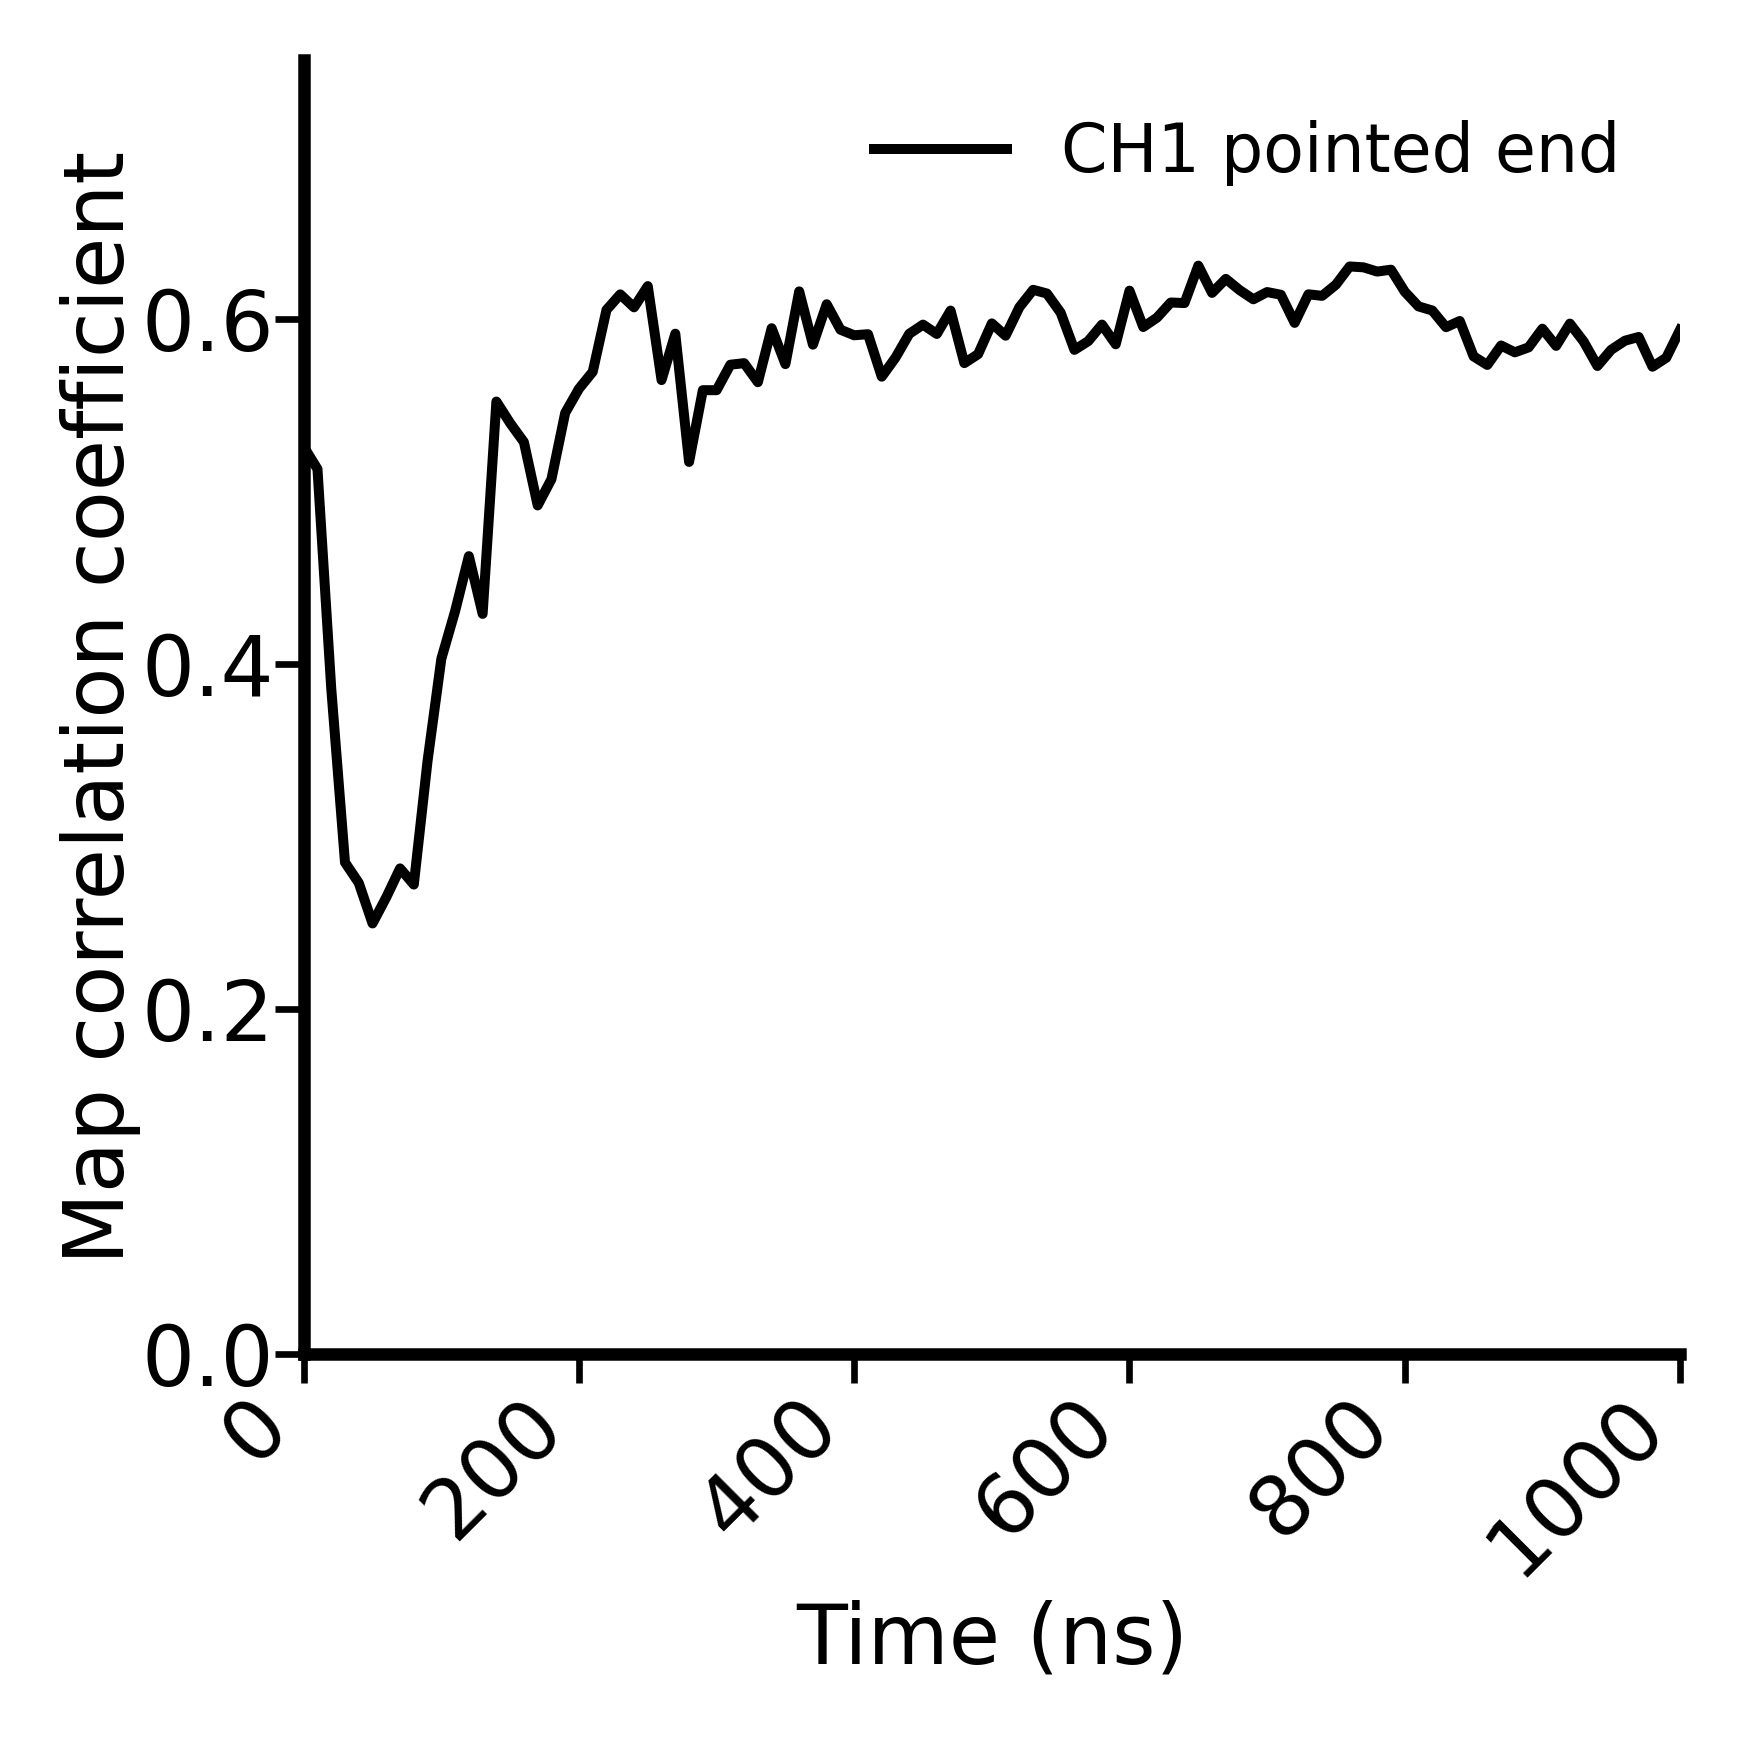

In [67]:
plt.figure(figsize=(3,3), dpi=600)

for (label, corr, pos) in results:
    time_axis = np.arange(len(corr)) * 10  # adjust multiplier to match your timestep in ns
    plt.plot(
        time_axis,
        corr,
        color="black",
        linewidth=1.2,
        label=label,
        linestyle='-'
    )

plt.margins(x=0)
plt.grid(False)

for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(fontsize=8, loc="best", frameon=False)

plt.xlabel("Time (ns)", fontsize=10, labelpad=1)
plt.ylabel("Map correlation coefficient", fontsize=10, labelpad=0.1)
plt.ylim([0, 0.75])
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.gca().tick_params(pad=0.01)

plt.tight_layout()
plt.show()